### Prettraining on unlabeled data

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken", 
        "torch",
        "tensorflow"    
       ]

for pkg in pkgs:
    print(pkg,version(pkg))


matplotlib 3.10.8
numpy 2.4.4
tiktoken 0.12.0
torch 2.11.0
tensorflow 2.21.0


In [2]:
import torch
from all_input_blocks import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers":12,
    "drop_rate": 0.1,
    "qkv_bias": False 
}

In [3]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

In [4]:
import tiktoken
from all_input_blocks import generate_text_simple

def text_to_token_ids(text,tokeniser):
    encoded = tokeniser.encode(text,allowed_special = {"|<endoftext>|"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor


In [5]:
start_context = "Every effort moves you"
tokeniser = tiktoken.get_encoding("gpt2")
token_ids = text_to_token_ids(start_context,tokeniser)
token_ids

tensor([[6109, 3626, 6100,  345]])

In [6]:
def token_ids_to_text(token_ids,tokeniser):
    flat = token_ids.squeeze(0)
    return tokeniser.decode(flat.tolist())

token_ids_to_text(token_ids,tokeniser)

'Every effort moves you'

In [7]:
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context,tokeniser),
    max_new_tokens = 10, # no of new words to be generated 
    context_size = GPT_CONFIG_124M["context_length"] 
)

In [8]:
token_ids.shape

torch.Size([1, 14])

In [9]:
token_ids_to_text(token_ids,tokeniser)

'Every effort moves you rentingetic wasnم refres RexMeCHicular stren'

### Calculating text generation loss: cross-entropy and perplexity

In [10]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [11]:
with torch.no_grad():
    logits = model(inputs)

In [12]:
logits.shape

torch.Size([2, 3, 50257])

In [13]:
logits.flatten(0,1).shape


torch.Size([6, 50257])

In [14]:
targets.shape

torch.Size([2, 3])

In [15]:
targets.flatten(0).shape

torch.Size([6])

cross-entropy loss 
1. convert logtis to probability
2. take log of probability
average log of probability
minimise - average log of probability to 0 so that probability tends to 1

In [16]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten(0)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
loss

tensor(10.7940)

### Calculating the training and validation set losses

In [17]:
with open("the-verdict.txt","r",encoding="utf-8") as f:
    text_data = f.read()

In [18]:
text_data[:99];

In [19]:
total_characters = len(text_data)
total_tokens = len(tokeniser.encode(text_data))
print(f" total_characters: {total_characters}, total_tokens: {total_tokens}")

 total_characters: 20479, total_tokens: 5145


In [20]:
from all_input_blocks import create_dataloader_v1

train_ratio = 0.90
split_idx = int(train_ratio*len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


In [21]:
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last = False,
    shuffle=False,
    num_workers=0
)


In [22]:
for x, y in train_loader:
    pass
print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])


In [23]:
for x, y in val_loader:
    print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])


In [24]:
#print num of elements in training and validation set
no_train_token = 0
no_val_token = 0
# x input_batch
# y target_batch
for x,y in train_loader:
    no_train_token += x.numel()

for x,y in val_loader:
    no_val_token += x.numel()
    
print(f"No. of Training token: {no_train_token}")
print(f"No. of Validating token: {no_val_token}")
print(f"No. of total token: {no_train_token+no_val_token}")

No. of Training token: 4608
No. of Validating token: 512
No. of total token: 5120


In [25]:
def calc_loss_batch(input_batch,target_batch,model,device):
    input_batch,target_batch = input_batch.to(device),target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten(0))
    return loss

def calc_loss_loader(data_loader,model,device,num_batches=None):
    total_loss = 0
    if len(data_loader) ==0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches,len(data_loader))

    for i, (input_batch,target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss = calc_loss_batch(input_batch,target_batch,model,device)
            total_loss += loss.item()
        else:
            break
    return total_loss/num_batches

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [31]:
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader,model,device)
    val_loss = calc_loss_loader(val_loader,model,device)

print("Train loss:", train_loss)
print("Var loss:", val_loss)

Train loss: 10.98758347829183
Var loss: 10.981106758117676


In [32]:
#Perplexity
torch.exp(torch.tensor([train_loss]))

tensor([59135.2930])

### Training an LLM

In [45]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                      eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    #main training loop
    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch, in train_loader:
            optimizer.zero_grad() # reset loss gradient from prev batch
            loss = calc_loss_batch(input_batch,target_batch,model,device)
            loss.backward() # calculate loss gradient
            optimizer.step() # update model weight using loss gradient
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1}(Step{global_step:06d}):"
                     f"Train_loss {train_loss:3f}, Val loss {val_loss:3f}")

        generate_and_print_sample(
            model,tokenizer,device,start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device,eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader,model,device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader,model,device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss
    
def generate_and_print_sample(model,tokenizer,device,start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context,tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model = model,
            idx = encoded,
            max_new_tokens = 50, # no of new words to be generated 
            context_size = context_size )
        decoded_text = token_ids_to_text(token_ids,tokenizer)
        print(decoded_text.replace("\n", " "))
        model.train()       
            

In [40]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay=0.1)

In [43]:
tokenizer = tiktoken.get_encoding("gpt2")

In [46]:
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader,val_loader,optimizer, device,
    num_epochs=num_epochs, eval_freq=5,eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1(Step000000):Train_loss 6.943817, Val loss 7.234920
Ep 1(Step000005):Train_loss 6.128423, Val loss 6.649946
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 2(Step000010):Train_loss 5.779275, Val loss 6.496413
Ep 2(Step000015):Train_loss 5.559248, Val loss 6.600358
Every effort moves you, and I had been. Gisburn, and I had the of the of the--and, and I had been. Gis. I had the the of the, and I had been, and, and I had to to the of
Ep 3(Step000020):Train_loss 4.871039, Val loss 6.272211
Ep 3(Step000025):Train_loss 4.311031, Val loss 6.255059
Every effort moves you know the                                                
Ep 4(Step000030):Train_loss 3.709335, Val loss 6.156767
Ep 4(Step000035):Train_loss 3.150943, Val loss 6.149798
Every effort moves you know it was not that the picture--I to the fact by the last I felt to have to see it the fact, and in the fact the moment--as Jack's a

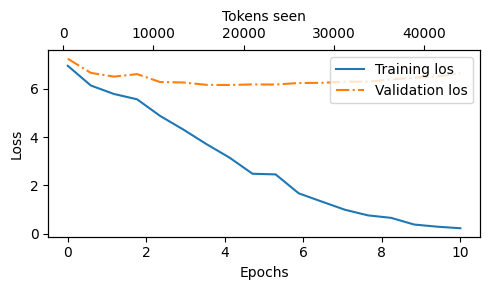

In [51]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))

    ax1.plot(epochs_seen, train_losses, label="Training los")
    ax1.plot(epochs_seen, val_losses, linestyle = "-.", label="Validation los")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer="True"))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0,num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen,train_losses,val_losses)